# Define constants

In [1]:
FEATURES_DIR = "../../features"
MODELS_DIR = "../../svm-models"
RANDOM_STATE = 42

import os
from pathlib import Path
import math
import random
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Load models and features

In [2]:
feature_files = sorted(Path(FEATURES_DIR).glob("*-noisy.npz"))
model_dirs = sorted(
    path
    for path in Path(MODELS_DIR).rglob("*")
    if path.is_dir()
    and (path / "label_encoder.pkl").is_file()
    and (path / "model.pkl").is_file()
    and (path / "scaler.pkl").is_file()
)

if not feature_files:
    raise FileNotFoundError(f"No feature files found in {FEATURES_DIR}")

if not model_dirs:
    raise FileNotFoundError(
        f"No model directories with label_encoder.pkl, model.pkl, and scaler.pkl found in {MODELS_DIR}"
    )

feature_cache = {}
for feature_path in feature_files:
    with np.load(feature_path, allow_pickle=True) as data:
        feature_cache[feature_path.stem] = {
            "features": data["features"],
            "labels": data["labels"],
        }

model_cache = {}
for model_dir in model_dirs:
    model_name = str(model_dir.relative_to(Path(MODELS_DIR)))
    model_cache[model_name] = {
        "label_encoder": joblib.load(model_dir / "label_encoder.pkl"),
        "model": joblib.load(model_dir / "model.pkl"),
        "scaler": joblib.load(model_dir / "scaler.pkl"),
    }

print(f"Loaded {len(model_dirs)} models and {len(feature_files)} feature sets.")
print("Models:", list(model_cache.keys()))
print("Feature sets:", [path.stem for path in feature_files])

Loaded 2 models and 4 feature sets.
Models: ['opus', 'opus-tuning']
Feature sets: ['opus-noisy', 'opus_pcm-noisy', 'pcm_s16le-noisy', 'pcm_s32le-noisy']


/home/seya/code/chord-detection/training/.venv/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/seya/code/chord-detection/training/.venv/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.6.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/seya/code/chord-detection/training/.venv/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator S

# Evaluation (transform)


[1/2] Evaluating model: opus


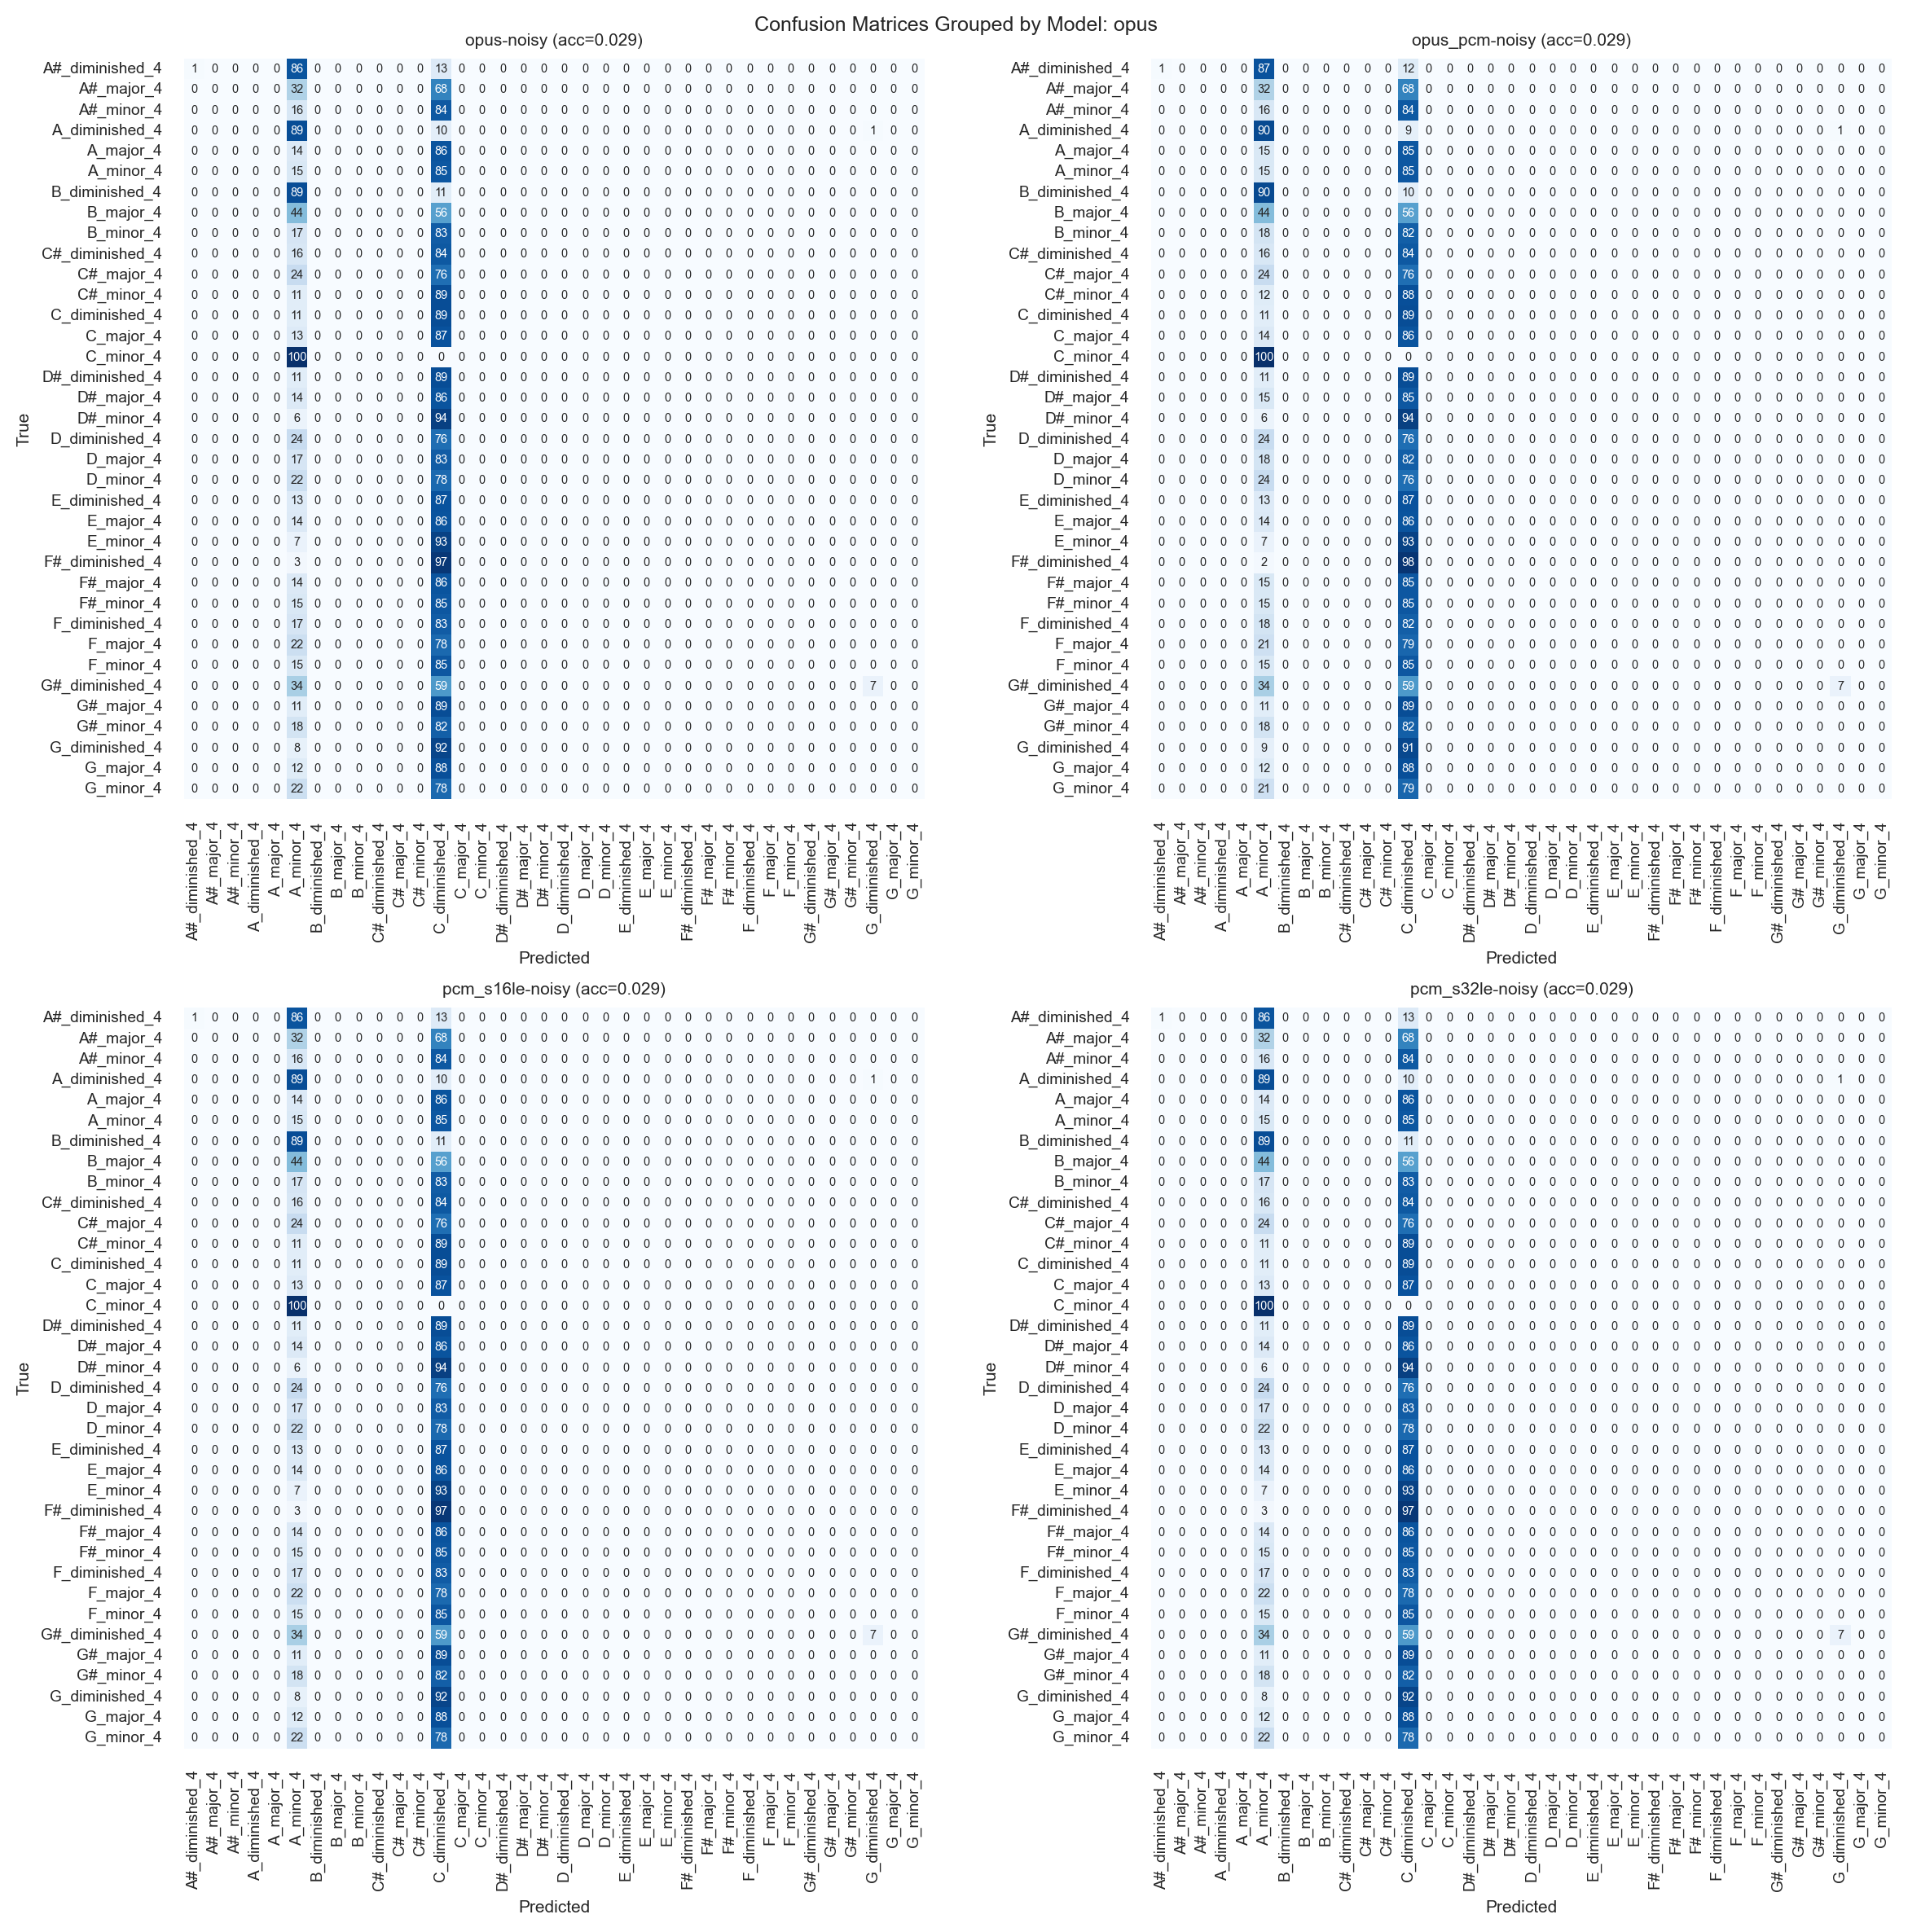

Finished model: opus

[2/2] Evaluating model: opus-tuning


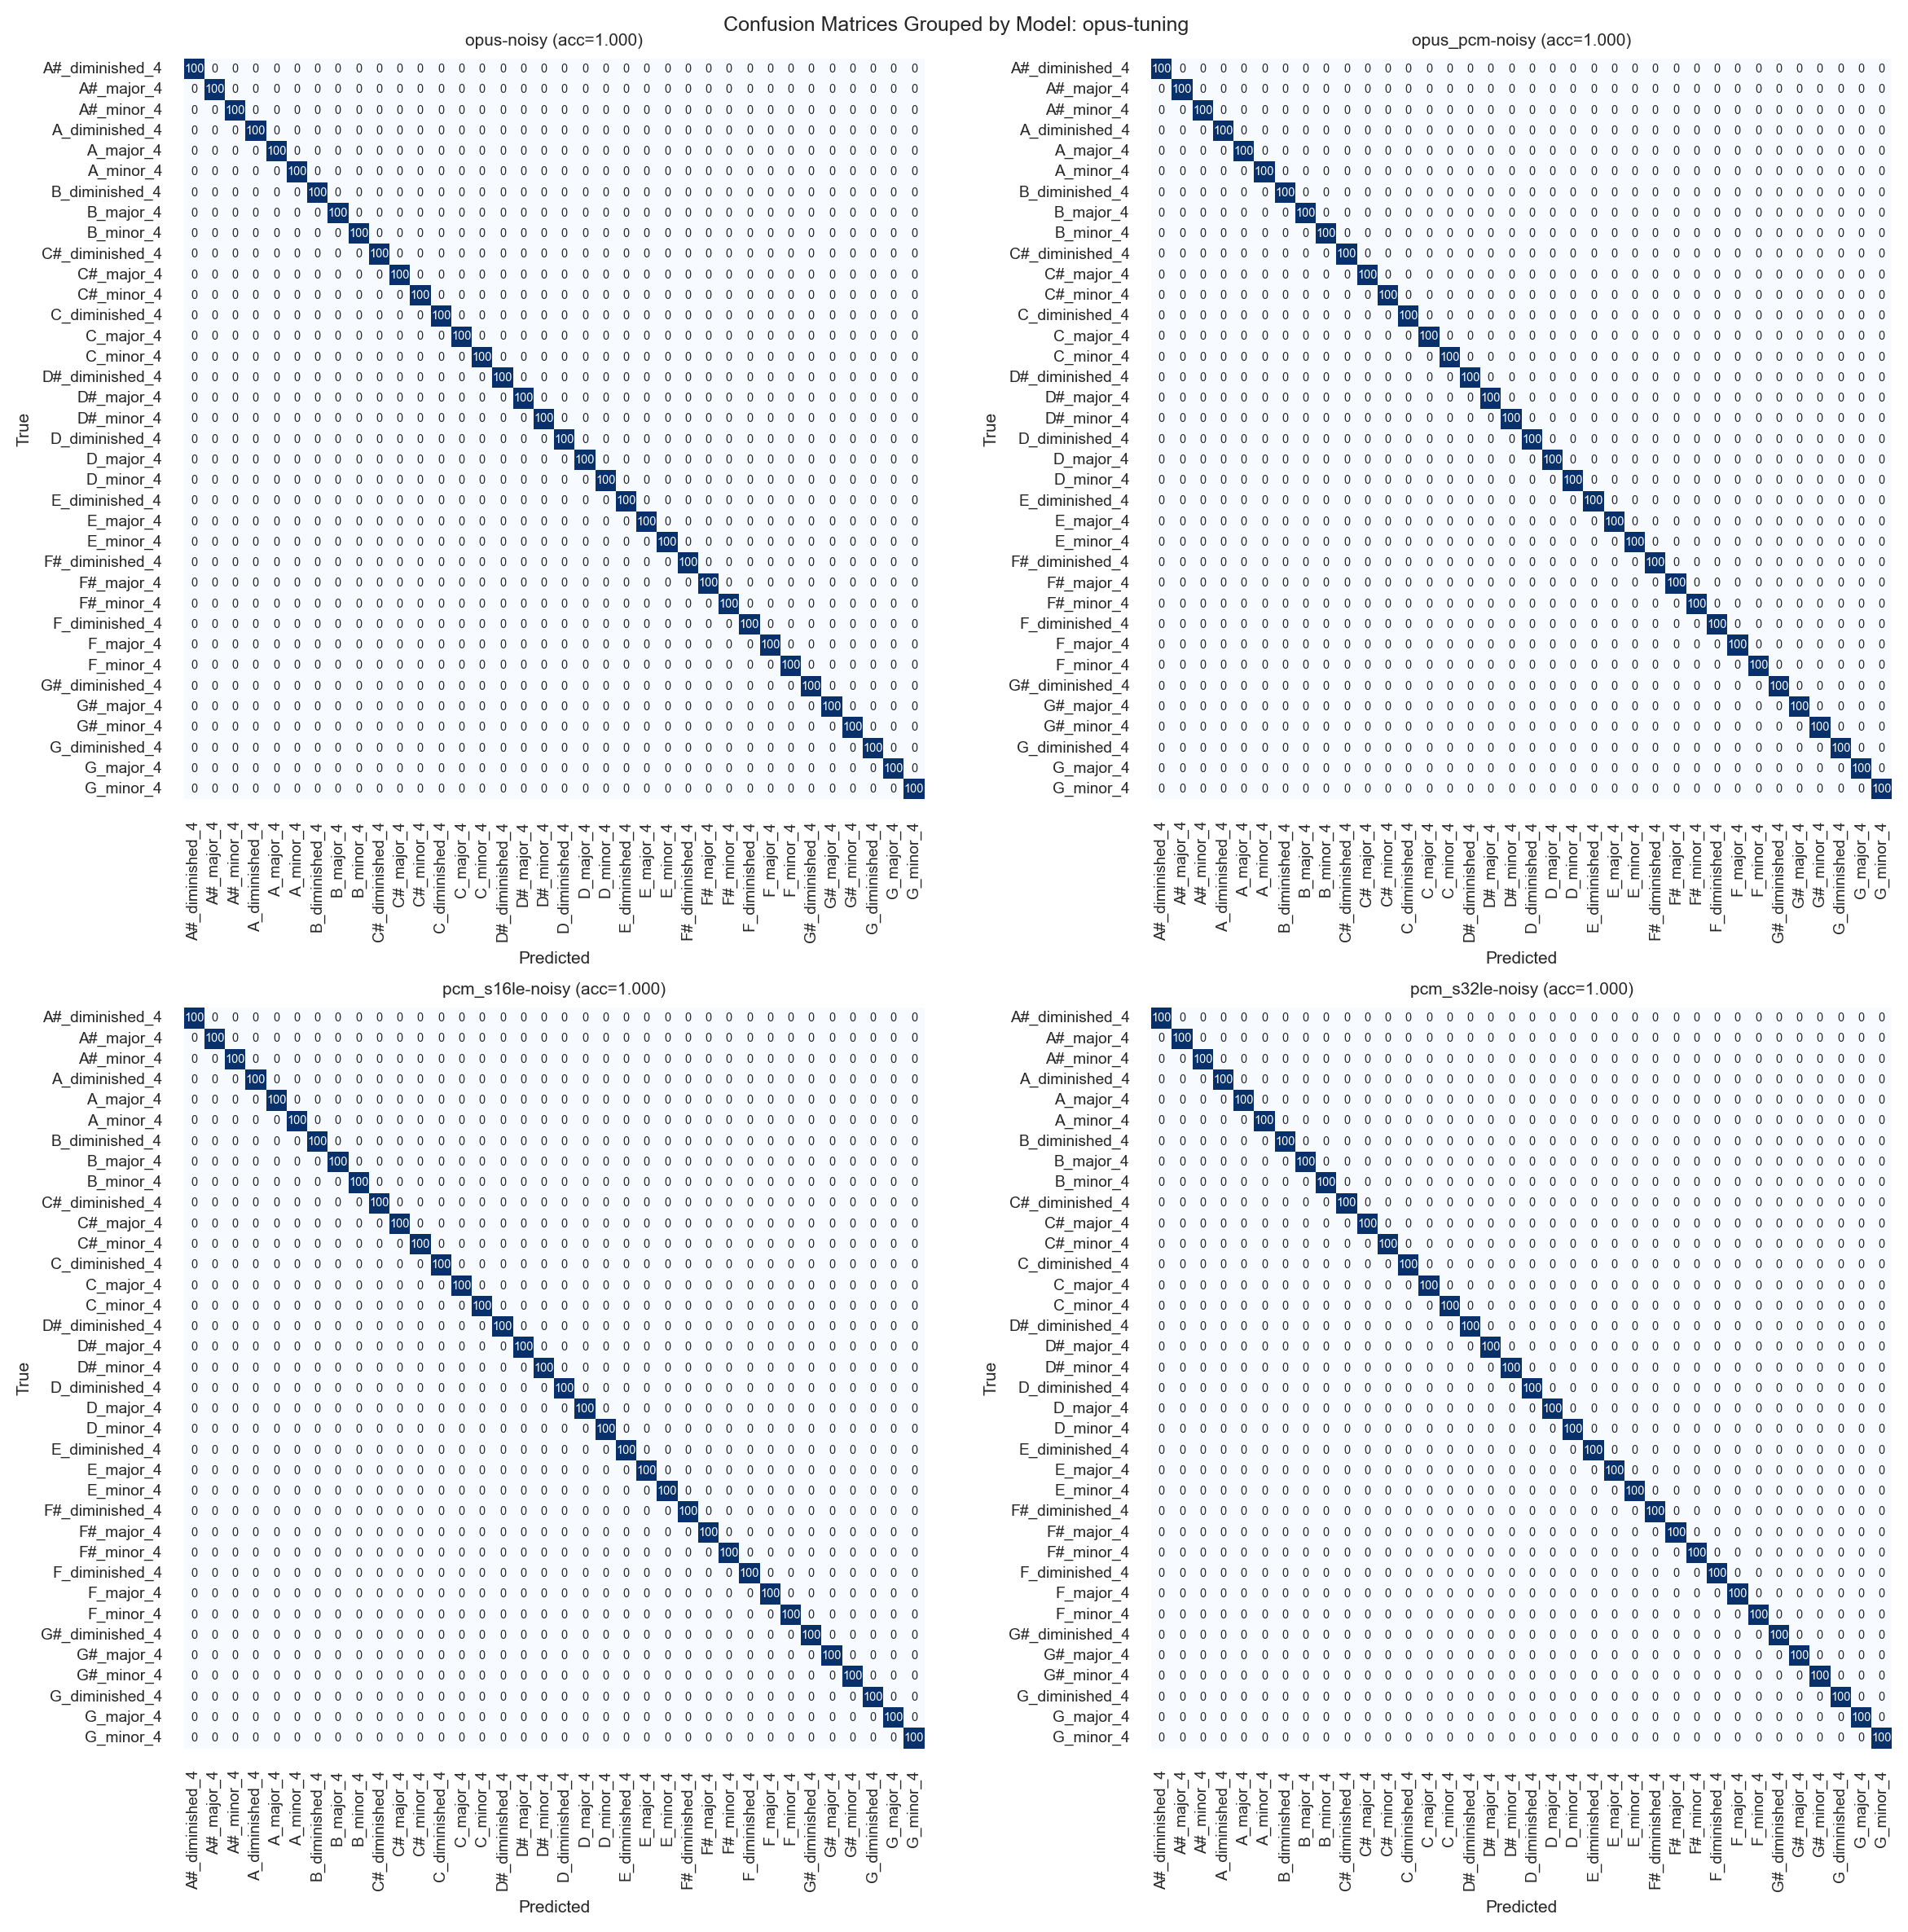

Finished model: opus-tuning

Done. Generated up to 8 confusion matrices.


In [ ]:
%config InlineBackend.figure_format = 'retina'

def prepare_features_for_svm(features: np.ndarray) -> np.ndarray:
    if features.ndim < 2:
        raise ValueError(f"Unexpected feature shape: {features.shape}")
    if features.ndim == 2:
        return features
    return features.reshape(features.shape[0], -1)


def predict_safely(model, scaler, features: np.ndarray) -> np.ndarray:
    # Flatten and scale features before SVM inference.
    flattened = prepare_features_for_svm(features)
    scaled = scaler.transform(flattened)
    return model.predict(scaled)

results = {}
sns.set_theme(font_scale=0.625)

model_items = list(model_cache.items())

for model_index, (model_name, model_bundle) in enumerate(model_items, start=1):
    print(f"\n[{model_index}/{len(model_items)}] Evaluating model: {model_name}")

    model = model_bundle["model"]
    scaler = model_bundle["scaler"]
    label_encoder = model_bundle["label_encoder"]
    results[model_name] = {}

    n_features = len(feature_files)
    n_cols = min(2, n_features)
    n_rows = math.ceil(n_features / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 6 * n_rows),
        squeeze=False,
    )

    for feature_index, feature_path in enumerate(feature_files):
        feature_name = feature_path.stem
        ax = axes[feature_index // n_cols][feature_index % n_cols]

        dataset = feature_cache[feature_name]
        x = dataset["features"]
        labels = dataset["labels"]

        class_labels = [str(label) for label in label_encoder.classes_]
        y_true = label_encoder.transform(labels)

        predictions = predict_safely(model, scaler, x)

        if np.asarray(predictions).dtype.kind in {"U", "S", "O"}:
            y_pred = label_encoder.transform(predictions)
        else:
            y_pred = np.asarray(predictions, dtype=np.int64)

        if y_pred.ndim != 1 or y_pred.shape[0] != y_true.shape[0]:
            ax.axis("off")
            ax.text(
                0.5,
                0.5,
                "Prediction shape mismatch\nmodel output != labels",
                ha="center",
                va="center",
                fontsize=10,
            )
            results[model_name][feature_name] = {
                "error": "Prediction shape mismatch",
                "prediction_shape": tuple(np.asarray(predictions).shape),
                "label_shape": tuple(np.asarray(y_true).shape),
            }
            continue

        cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_labels)))
        accuracy = float(np.mean(y_true == y_pred))
        report = classification_report(
            y_true,
            y_pred,
            labels=np.arange(len(class_labels)),
            target_names=class_labels,
            zero_division=0,
        )

        results[model_name][feature_name] = {
            "confusion_matrix": cm,
            "accuracy": accuracy,
            "classification_report": report,
            "classes": class_labels,
        }

        sns.heatmap(
            cm,
            ax=ax,
            annot=True,
            annot_kws={"fontsize": "x-small"},
            cmap="Blues",
            cbar=False,
            fmt="d",
            xticklabels=class_labels,
            yticklabels=class_labels,
            square=True,
        )
        ax.set_aspect("equal", adjustable="box")
        ax.set_title(f"{feature_name} (acc={accuracy:.3f})")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

    for empty_axis in axes.ravel()[n_features:]:
        empty_axis.axis("off")

    fig.suptitle(f"Confusion Matrices Grouped by Model: {model_name}")
    plt.tight_layout()
    plt.show()

    print(f"Finished model: {model_name}")

print(f"\nDone. Generated up to {len(model_items) * len(feature_files)} confusion matrices.")

# Result (transform)

In [ ]:
REPORT_ONLY_INACCURACIES = True
DECIMALS = 4

per_class_reports = []

for model_name, feature_results in results.items():
    for feature_name, result in feature_results.items():
        if (
            "confusion_matrix" not in result
            or "classes" not in result
            or "accuracy" not in result
        ):
            continue

        overall_accuracy = result["accuracy"]
        cm = np.asarray(result["confusion_matrix"], dtype=np.float64)
        class_labels = [str(label) for label in result["classes"]]

        if cm.shape[0] != cm.shape[1] or cm.shape[0] != len(class_labels):
            print(
                f"Skipping {model_name} x {feature_name}: invalid confusion matrix shape {cm.shape}"
            )
            continue

        support = cm.sum(axis=1)
        correct = np.diag(cm)
        class_accuracy = np.divide(
            correct,
            support,
            out=np.full_like(correct, np.nan, dtype=np.float64),
            where=support > 0,
        )

        per_class_reports.append(
            {
                "model": model_name,
                "feature": feature_name,
                "overall_accuracy": overall_accuracy,
                "classes": class_labels,
                "class_accuracy": class_accuracy,
                "correct": correct,
                "support": support,
            }
        )

if not per_class_reports:
    print("No model-feature pairs matched the reporting filter.")
else:
    scope_text = "below 100% accuracy" if REPORT_ONLY_INACCURACIES else "all evaluated pairs"
    print(f"Per-class accuracy report for {scope_text}:")

    for report in per_class_reports:
        print(
            f"\n{report['model']} x {report['feature']} | overall_accuracy={report['overall_accuracy']:.{DECIMALS}%}"
        )
        print("Class accuracies (accuracy = correct/support):")

        for label, acc, corr, supp in zip(
            report["classes"],
            report["class_accuracy"],
            report["correct"],
            report["support"],
        ):
            if REPORT_ONLY_INACCURACIES and corr == supp:
              continue
            acc_text = "N/A" if np.isnan(acc) else f"{acc:.{DECIMALS}%}"
            print(f"  {label:>16} : {acc_text} ({int(corr)}/{int(supp)})")

Per-class accuracy report for below 100% accuracy:

opus x opus-noisy | overall_accuracy=2.9167%
Class accuracies (accuracy = correct/support):
   A#_diminished_4 : 1.0000% (1/100)
        A#_major_4 : 0.0000% (0/100)
        A#_minor_4 : 0.0000% (0/100)
    A_diminished_4 : 0.0000% (0/100)
         A_major_4 : 0.0000% (0/100)
         A_minor_4 : 15.0000% (15/100)
    B_diminished_4 : 0.0000% (0/100)
         B_major_4 : 0.0000% (0/100)
         B_minor_4 : 0.0000% (0/100)
   C#_diminished_4 : 0.0000% (0/100)
        C#_major_4 : 0.0000% (0/100)
        C#_minor_4 : 0.0000% (0/100)
    C_diminished_4 : 89.0000% (89/100)
         C_major_4 : 0.0000% (0/100)
         C_minor_4 : 0.0000% (0/100)
   D#_diminished_4 : 0.0000% (0/100)
        D#_major_4 : 0.0000% (0/100)
        D#_minor_4 : 0.0000% (0/100)
    D_diminished_4 : 0.0000% (0/100)
         D_major_4 : 0.0000% (0/100)
         D_minor_4 : 0.0000% (0/100)
    E_diminished_4 : 0.0000% (0/100)
         E_major_4 : 0.0000% (0/100)
 

# Evaluation (fit_transform)


[1/2] Evaluating model: opus


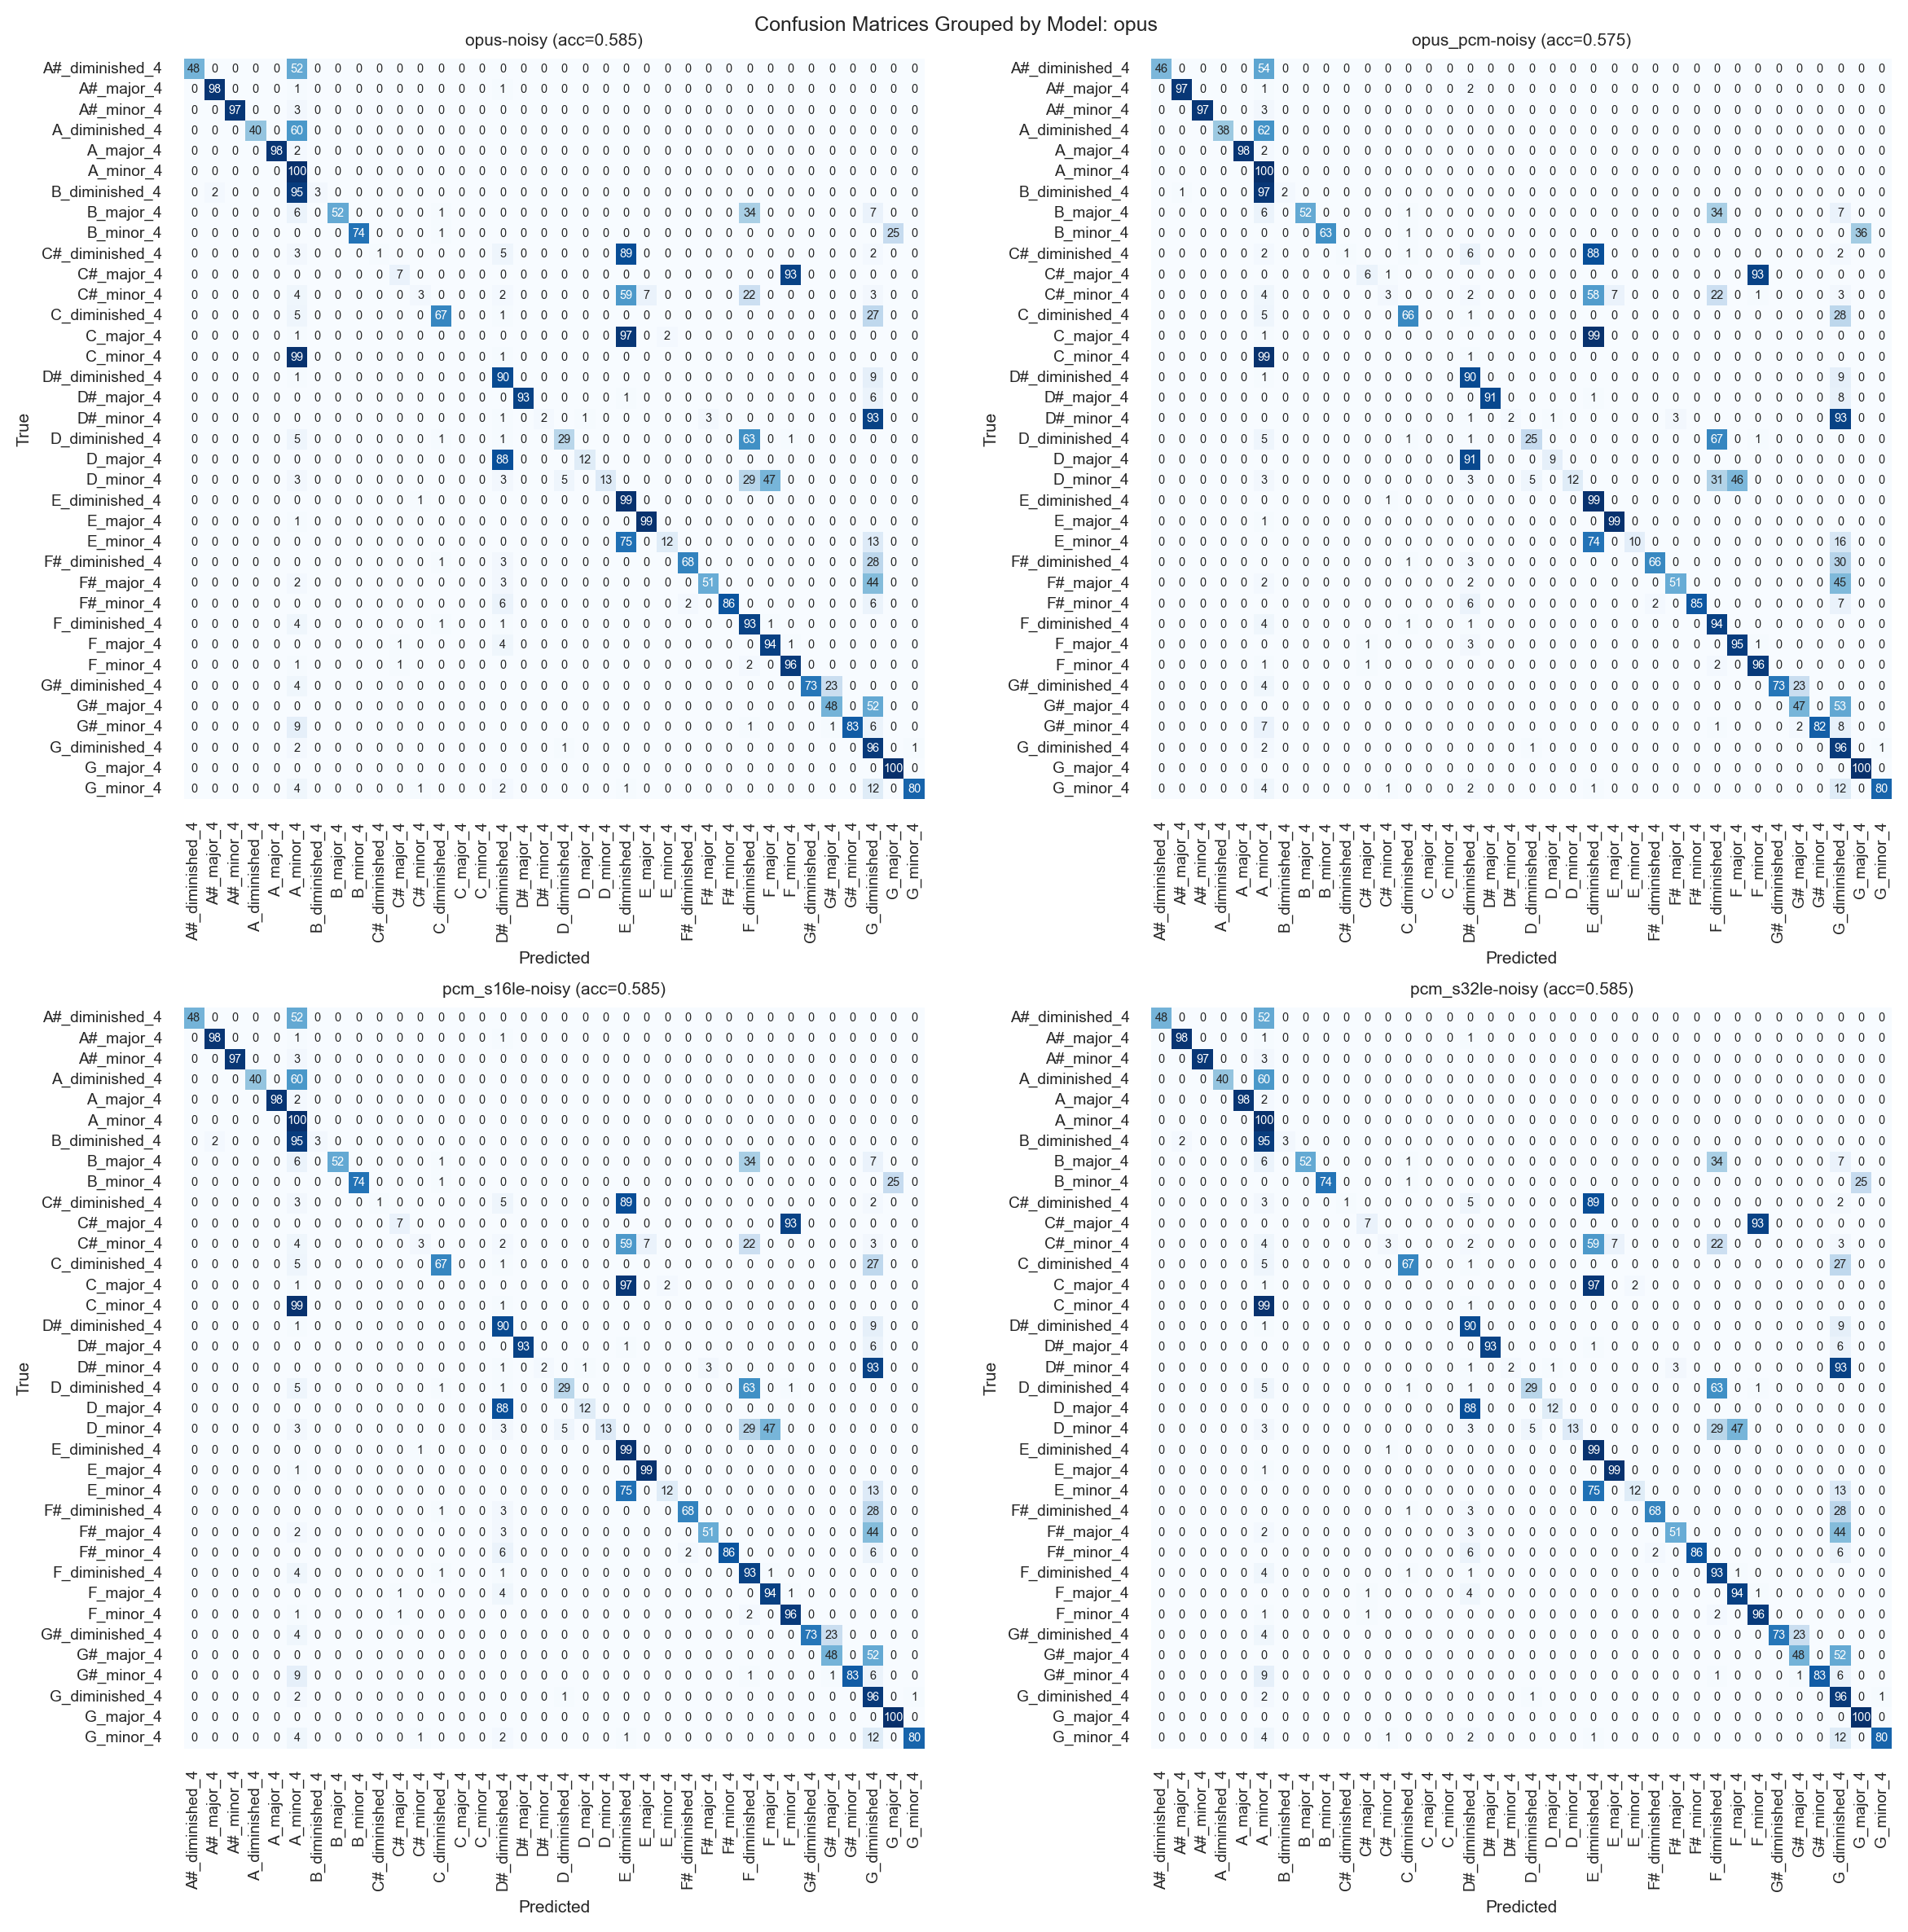

Finished model: opus

[2/2] Evaluating model: opus-tuning


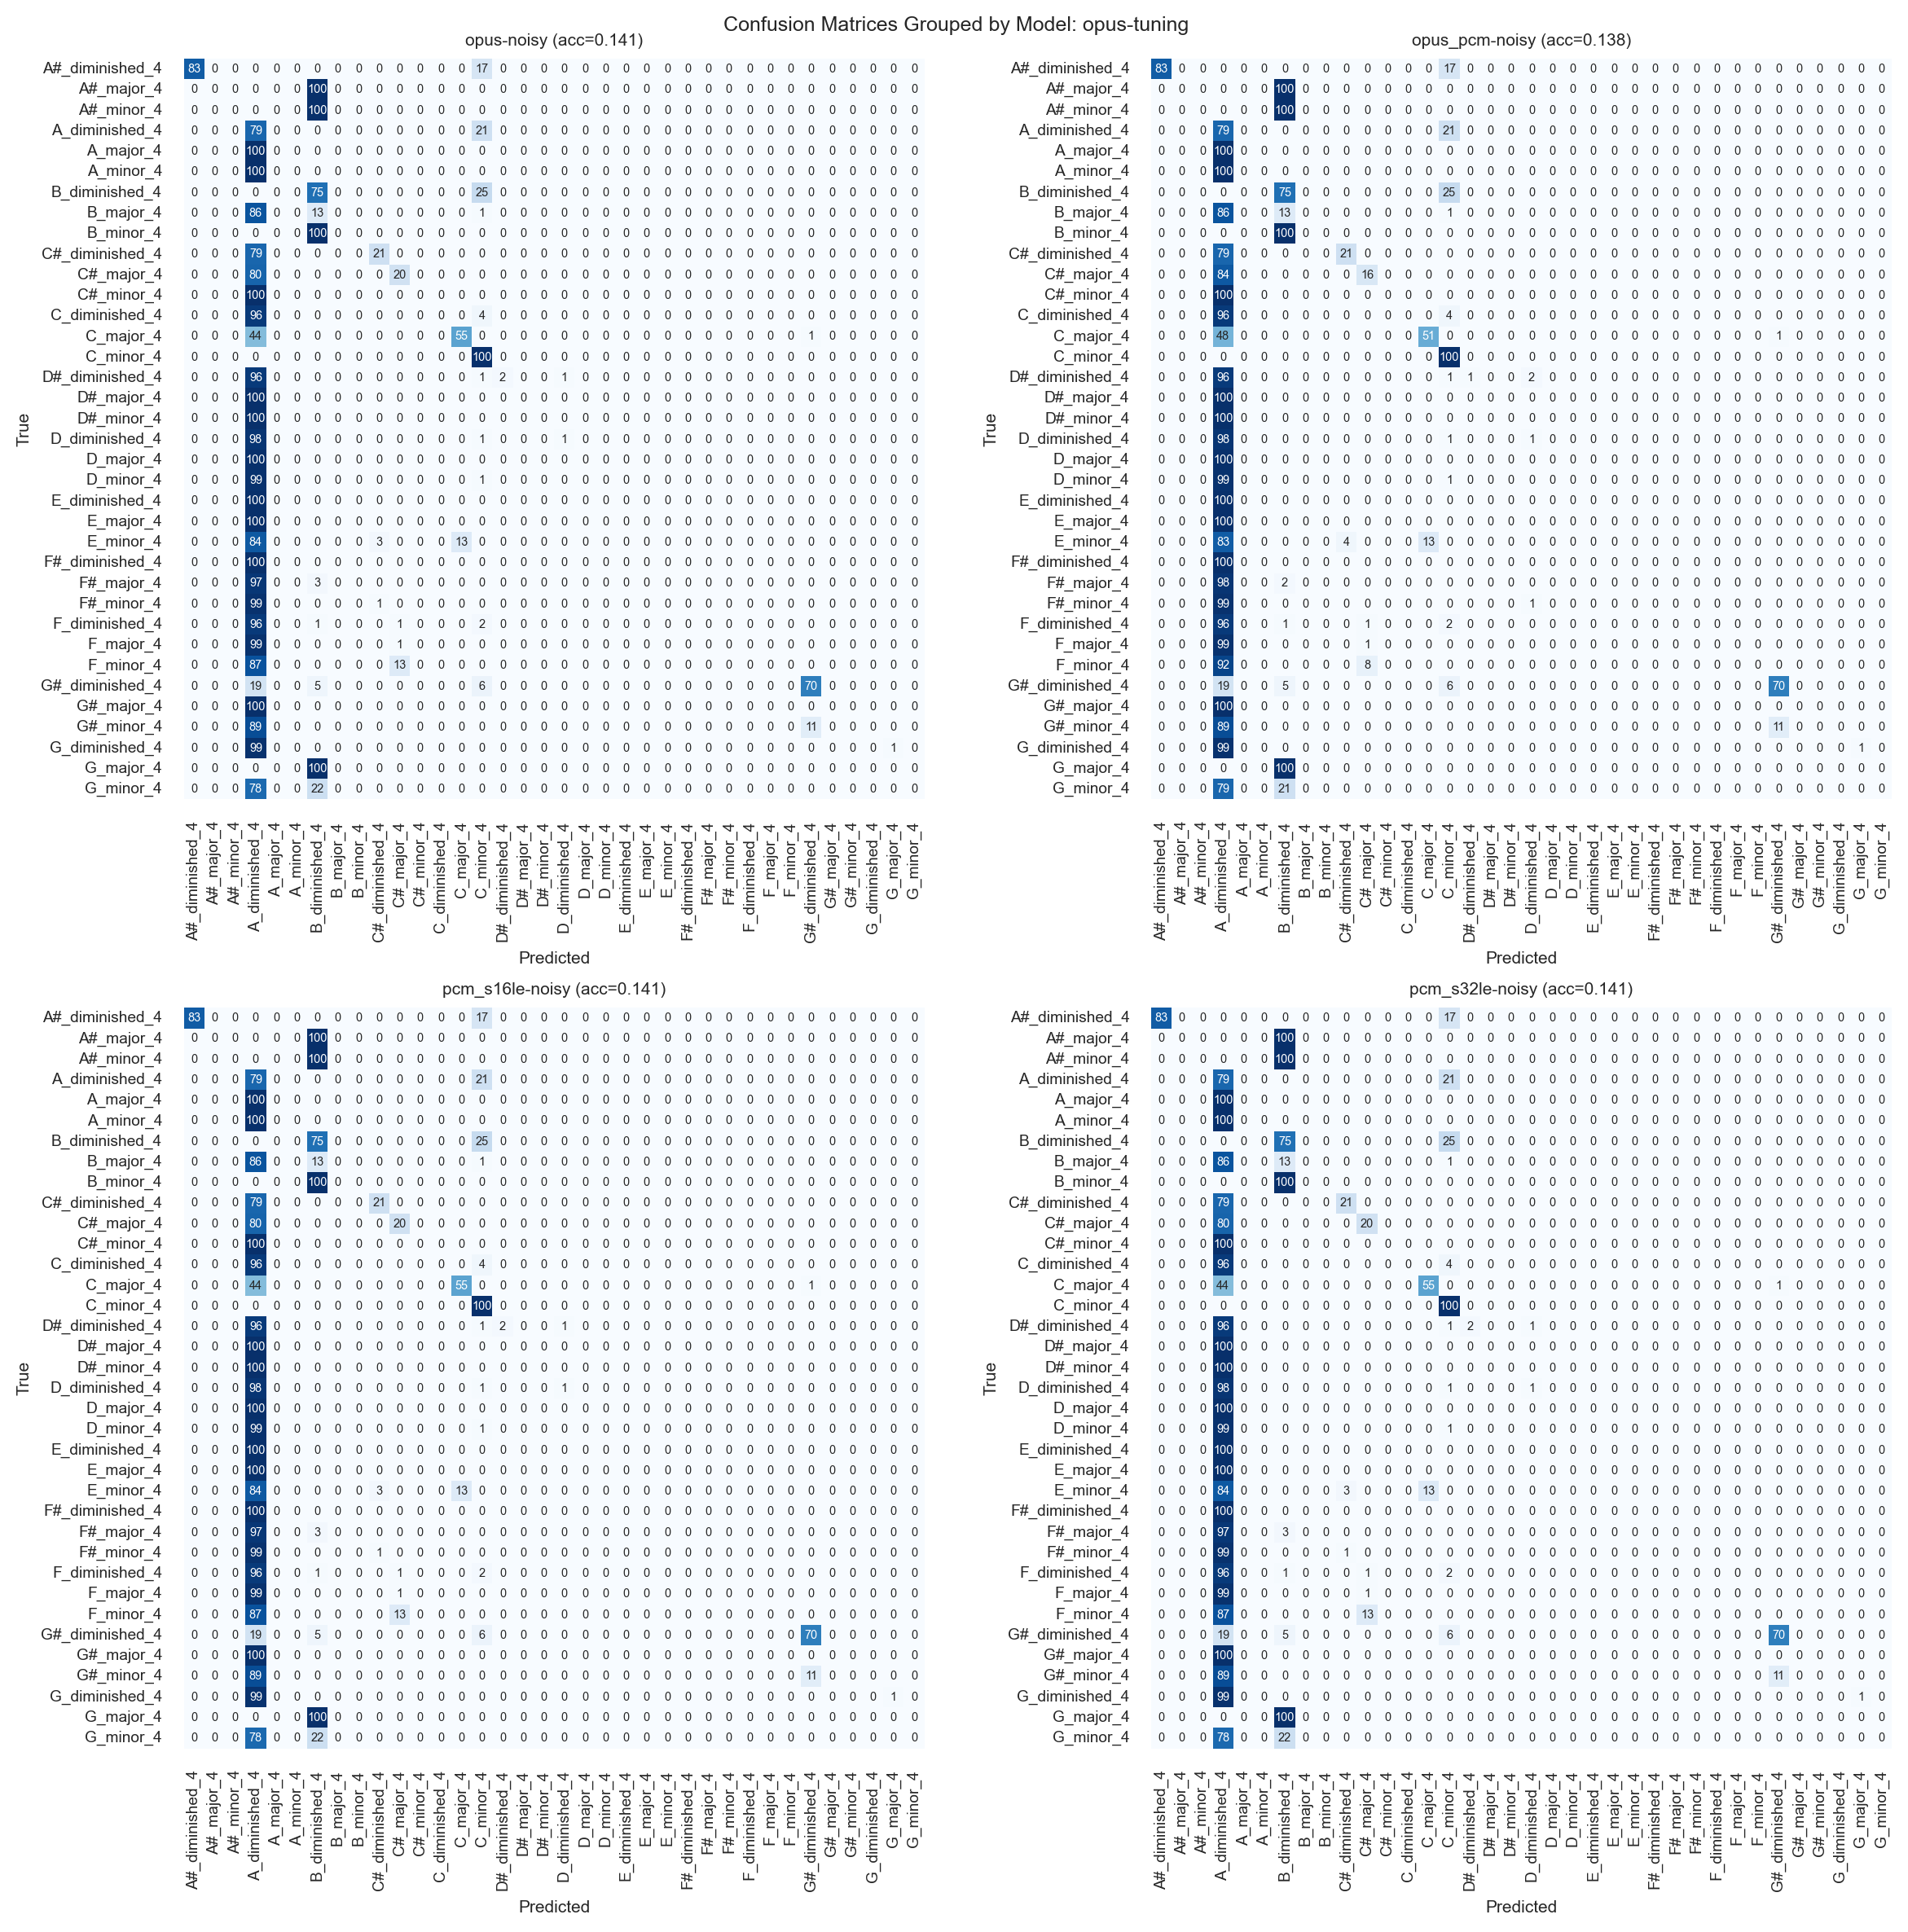

Finished model: opus-tuning

Done. Generated up to 8 confusion matrices.


In [3]:
%config InlineBackend.figure_format = 'retina'

def prepare_features_for_svm(features: np.ndarray) -> np.ndarray:
    if features.ndim < 2:
        raise ValueError(f"Unexpected feature shape: {features.shape}")
    if features.ndim == 2:
        return features
    return features.reshape(features.shape[0], -1)


def predict_safely(model, scaler, features: np.ndarray) -> np.ndarray:
    # Flatten and scale features before SVM inference.
    flattened = prepare_features_for_svm(features)
    scaled = scaler.fit_transform(flattened)
    return model.predict(scaled)

results = {}
sns.set_theme(font_scale=0.625)

model_items = list(model_cache.items())

for model_index, (model_name, model_bundle) in enumerate(model_items, start=1):
    print(f"\n[{model_index}/{len(model_items)}] Evaluating model: {model_name}")

    model = model_bundle["model"]
    scaler = model_bundle["scaler"]
    label_encoder = model_bundle["label_encoder"]
    results[model_name] = {}

    n_features = len(feature_files)
    n_cols = min(2, n_features)
    n_rows = math.ceil(n_features / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 6 * n_rows),
        squeeze=False,
    )

    for feature_index, feature_path in enumerate(feature_files):
        feature_name = feature_path.stem
        ax = axes[feature_index // n_cols][feature_index % n_cols]

        dataset = feature_cache[feature_name]
        x = dataset["features"]
        labels = dataset["labels"]

        class_labels = [str(label) for label in label_encoder.classes_]
        y_true = label_encoder.transform(labels)

        predictions = predict_safely(model, scaler, x)

        if np.asarray(predictions).dtype.kind in {"U", "S", "O"}:
            y_pred = label_encoder.transform(predictions)
        else:
            y_pred = np.asarray(predictions, dtype=np.int64)

        if y_pred.ndim != 1 or y_pred.shape[0] != y_true.shape[0]:
            ax.axis("off")
            ax.text(
                0.5,
                0.5,
                "Prediction shape mismatch\nmodel output != labels",
                ha="center",
                va="center",
                fontsize=10,
            )
            results[model_name][feature_name] = {
                "error": "Prediction shape mismatch",
                "prediction_shape": tuple(np.asarray(predictions).shape),
                "label_shape": tuple(np.asarray(y_true).shape),
            }
            continue

        cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_labels)))
        accuracy = float(np.mean(y_true == y_pred))
        report = classification_report(
            y_true,
            y_pred,
            labels=np.arange(len(class_labels)),
            target_names=class_labels,
            zero_division=0,
        )

        results[model_name][feature_name] = {
            "confusion_matrix": cm,
            "accuracy": accuracy,
            "classification_report": report,
            "classes": class_labels,
        }

        sns.heatmap(
            cm,
            ax=ax,
            annot=True,
            annot_kws={"fontsize": "x-small"},
            cmap="Blues",
            cbar=False,
            fmt="d",
            xticklabels=class_labels,
            yticklabels=class_labels,
            square=True,
        )
        ax.set_aspect("equal", adjustable="box")
        ax.set_title(f"{feature_name} (acc={accuracy:.3f})")
        ax.set_xlabel("Predicted")
        ax.set_ylabel("True")

    for empty_axis in axes.ravel()[n_features:]:
        empty_axis.axis("off")

    fig.suptitle(f"Confusion Matrices Grouped by Model: {model_name}")
    plt.tight_layout()
    plt.show()

    print(f"Finished model: {model_name}")

print(f"\nDone. Generated up to {len(model_items) * len(feature_files)} confusion matrices.")

# Result (fit_transform)

In [4]:
REPORT_ONLY_INACCURACIES = True
DECIMALS = 4

per_class_reports = []

for model_name, feature_results in results.items():
    for feature_name, result in feature_results.items():
        if (
            "confusion_matrix" not in result
            or "classes" not in result
            or "accuracy" not in result
        ):
            continue

        overall_accuracy = result["accuracy"]
        cm = np.asarray(result["confusion_matrix"], dtype=np.float64)
        class_labels = [str(label) for label in result["classes"]]

        if cm.shape[0] != cm.shape[1] or cm.shape[0] != len(class_labels):
            print(
                f"Skipping {model_name} x {feature_name}: invalid confusion matrix shape {cm.shape}"
            )
            continue

        support = cm.sum(axis=1)
        correct = np.diag(cm)
        class_accuracy = np.divide(
            correct,
            support,
            out=np.full_like(correct, np.nan, dtype=np.float64),
            where=support > 0,
        )

        per_class_reports.append(
            {
                "model": model_name,
                "feature": feature_name,
                "overall_accuracy": overall_accuracy,
                "classes": class_labels,
                "class_accuracy": class_accuracy,
                "correct": correct,
                "support": support,
            }
        )

if not per_class_reports:
    print("No model-feature pairs matched the reporting filter.")
else:
    scope_text = "below 100% accuracy" if REPORT_ONLY_INACCURACIES else "all evaluated pairs"
    print(f"Per-class accuracy report for {scope_text}:")

    for report in per_class_reports:
        print(
            f"\n{report['model']} x {report['feature']} | overall_accuracy={report['overall_accuracy']:.{DECIMALS}%}"
        )
        print("Class accuracies (accuracy = correct/support):")

        for label, acc, corr, supp in zip(
            report["classes"],
            report["class_accuracy"],
            report["correct"],
            report["support"],
        ):
            if REPORT_ONLY_INACCURACIES and corr == supp:
              continue
            acc_text = "N/A" if np.isnan(acc) else f"{acc:.{DECIMALS}%}"
            print(f"  {label:>16} : {acc_text} ({int(corr)}/{int(supp)})")

Per-class accuracy report for below 100% accuracy:

opus x opus-noisy | overall_accuracy=58.4722%
Class accuracies (accuracy = correct/support):
   A#_diminished_4 : 48.0000% (48/100)
        A#_major_4 : 98.0000% (98/100)
        A#_minor_4 : 97.0000% (97/100)
    A_diminished_4 : 40.0000% (40/100)
         A_major_4 : 98.0000% (98/100)
    B_diminished_4 : 3.0000% (3/100)
         B_major_4 : 52.0000% (52/100)
         B_minor_4 : 74.0000% (74/100)
   C#_diminished_4 : 1.0000% (1/100)
        C#_major_4 : 7.0000% (7/100)
        C#_minor_4 : 3.0000% (3/100)
    C_diminished_4 : 67.0000% (67/100)
         C_major_4 : 0.0000% (0/100)
         C_minor_4 : 0.0000% (0/100)
   D#_diminished_4 : 90.0000% (90/100)
        D#_major_4 : 93.0000% (93/100)
        D#_minor_4 : 2.0000% (2/100)
    D_diminished_4 : 29.0000% (29/100)
         D_major_4 : 12.0000% (12/100)
         D_minor_4 : 13.0000% (13/100)
    E_diminished_4 : 99.0000% (99/100)
         E_major_4 : 99.0000% (99/100)
         E_

# Debugging

In [8]:
means = []

for model_index, (model_name, model_bundle) in enumerate(model_items, start=1):
    print(f"[{model_index}/{len(model_items)}] model: {model_name}")

    model = model_bundle["model"]
    scaler = model_bundle["scaler"]
    label_encoder = model_bundle["label_encoder"]

    means.append(scaler.mean_)
    print("Scaler mean:", scaler.mean_)

diff = list(set(means[0]) - set(means[1]))
print("Dataset difference (good if empty):", diff)

[1/2] model: opus
Scaler mean: [0.02006036 0.02332566 0.02561615 ... 0.00452329 0.00172533 0.00150171]
[2/2] model: opus-tuning
Scaler mean: [0.02006036 0.02332566 0.02561615 ... 0.00452329 0.00172533 0.00150171]
Dataset difference (good if empty): []
